# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [1]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    # Detectar si estamos en Codespaces o VS Code local
    if os.path.exists('/workspaces/TFMDS'):
        # Entorno Codespaces
        os.chdir('/workspaces/TFMDS')
    else:
        # En VS Code local, nos movemos al directorio raíz del proyecto
        project_dir = r'C:\Users\jmora\Documents\TFMDS'
        os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", os.getcwd() in sys.path)

Directorio de trabajo: /workspaces/TFMDS
Python path incluye proyecto: True


In [2]:
# ============================================================================
# IMPORTACIONES BASE Y VERSIÓN
# ============================================================================
import os, sys
import pandas as pd
import numpy as np
import time

import torch
import pytorch_lightning as pl
from neuralforecast import NeuralForecast, __version__ as nf_version
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE

# Importar utilidades desde la carpeta 'lib'
lib_dir = os.path.join(os.getcwd(), 'lib')
if lib_dir not in sys.path:
    sys.path.insert(0, lib_dir)

from lib.dl_utils import (
    preparar_datos_neuralforecast,
    preparar_variables_estaticas,
)
from lib.metricas import calcular_metricas, resumen_metricas
from lib.graficos_dl import (
    grafico_prediccion_diaria_agregada,
    grafico_prediccion_por_cluster,
    grafico_productos_por_cluster,
    dashboard_metricas_dl,
)

print(f"torch: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"neuralforecast: {nf_version}")

torch: 2.9.1+cu128
pytorch_lightning: 2.6.0
neuralforecast: 3.1.2


# Lectura de datos preparados para Deep Learning

In [3]:
# ============================================================================
# LECTURA DE DATOS
# ============================================================================

print("\n" + "="*100)
print("📂 CARGANDO DATOS PARA DEEP LEARNING")
print("="*100)

# Datos normalizados para entrenamiento
df_train_raw = pd.read_csv('datos/df_train_dl.csv', sep=';', parse_dates=['idSecuencia'])
df_test_raw = pd.read_csv('datos/df_test_dl.csv', sep=';', parse_dates=['idSecuencia'])

print(f"\n✅ Datos cargados:")
print(f"   Train: {df_train_raw.shape}")
print(f"   Test:  {df_test_raw.shape}")


📂 CARGANDO DATOS PARA DEEP LEARNING

✅ Datos cargados:
   Train: (625800, 27)
   Test:  (27714, 27)

✅ Datos cargados:
   Train: (625800, 27)
   Test:  (27714, 27)


# Preparación de datos para NeuralForecast

In [4]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA NEURALFORECAST
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO DATOS PARA NEURALFORECAST")
print("="*100)

# Convertir al formato NeuralForecast (unique_id, ds, y)
df_train_nf, df_test_nf = preparar_datos_neuralforecast(
    df_train_raw,
    df_test_raw,
    col_fecha='idSecuencia',
    col_producto='producto',
    col_target='udsVenta'
)

print(f"\n✅ Datos convertidos a formato NeuralForecast")
print(f"   Train NF: {df_train_nf.shape}")
print(f"   Test NF:  {df_test_nf.shape}")


🔧 PREPARANDO DATOS PARA NEURALFORECAST

✅ Datos convertidos a formato NeuralForecast
   Train NF: (625800, 27)
   Test NF:  (27714, 27)


# Configuración del modelo N-BEATS

## Preparar variables estáticas

In [5]:
# ============================================================================
# PREPARAR VARIABLES ESTÁTICAS
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO VARIABLES ESTÁTICAS")
print("="*100)

# Definir columnas estáticas (que no varían en el tiempo)
stat_exog_list = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']

# Separar variables estáticas en DataFrame aparte
df_train_nf, df_test_nf, static_df = preparar_variables_estaticas(
    df_train_nf,
    df_test_nf,
    stat_exog_list
)


🔧 PREPARANDO VARIABLES ESTÁTICAS

✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 23) (eliminadas 4 columnas)
   Test:  (27714, 23) (eliminadas 4 columnas)

✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 23) (eliminadas 4 columnas)
   Test:  (27714, 23) (eliminadas 4 columnas)


In [6]:
# =============================================================================
# LIMPIEZA DE FEATURES HISTÓRICAS (evitar NaN al inicio del test)
# =============================================================================

print("\n" + "="*100)
print("🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)")
print("="*100)

# Definir la lista de features históricas que usa el modelo
hist_exog_list = [
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'media_mes_anterior',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

# Comprobar existencia de columnas
def _check_missing(df, cols):
    return [c for c in cols if c not in df.columns]

missing_train = _check_missing(df_train_nf, hist_exog_list)
missing_test = _check_missing(df_test_nf, hist_exog_list)

if missing_train:
    print(f"⚠️ Faltan columnas en train: {missing_train}")
if missing_test:
    print(f"⚠️ Faltan columnas en test: {missing_test}")

cols_ok = [c for c in hist_exog_list if c in df_train_nf.columns and c in df_test_nf.columns]

if cols_ok:
    # Estadísticas antes
    na_train_before = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_before = int(df_test_nf[cols_ok].isna().sum().sum())

    # Forward fill por serie (unique_id) y rellenar remanentes al inicio con 0
    df_train_nf[cols_ok] = (
        df_train_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )
    df_test_nf[cols_ok] = (
        df_test_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )

    # Asegurar tipos numéricos (por si hubiera strings)
    for df_tmp in (df_train_nf, df_test_nf):
        for c in cols_ok:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce').fillna(0)

    # Estadísticas después
    na_train_after = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_after = int(df_test_nf[cols_ok].isna().sum().sum())

    print(f"✅ NaNs en train: {na_train_before} → {na_train_after}")
    print(f"✅ NaNs en test:  {na_test_before} → {na_test_after}")
else:
    print("⚠️ No hay columnas históricas válidas para limpiar.")

# Comprobación de contexto mínimo: filas previas por producto
min_hist = (
    df_train_nf.groupby('unique_id', observed=True)['ds']
    .count()
    .min()
)
print(f"ℹ️ Mínimo historial por producto en train: {min_hist} filas")
print("   Si es < input_size, considera reducir input_size o filtrar productos.")


🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)
✅ NaNs en train: 4 → 0
✅ NaNs en test:  0 → 0
ℹ️ Mínimo historial por producto en train: 700 filas
   Si es < input_size, considera reducir input_size o filtrar productos.
✅ NaNs en train: 4 → 0
✅ NaNs en test:  0 → 0
ℹ️ Mínimo historial por producto en train: 700 filas
   Si es < input_size, considera reducir input_size o filtrar productos.


## Configuración del modelo N-BEATS

N-BEATS (Neural Basis Expansion Analysis for Interpretable Time Series Forecasting) es una arquitectura
basada en bloques residuales que no usa variables exógenas en su forma estándar.
Los principales hiperparámetros son:
- **stack_types**: Tipo de pila (identity, trend, seasonality)
- **n_blocks**: Número de bloques por stack
- **mlp_units**: Unidades por capa en cada bloque (arquitectura de MLP)
- **n_harmonics**: Número de armónicos para el stack de seasonality
- **n_polynomials**: Grado de polinomios para el stack de trend

In [7]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO N-BEATS
# ============================================================================

print("\n" + "="*100)
print("🧠 CONFIGURANDO MODELO N-BEATS")
print("="*100)

# Horizonte de predicción (30 días)
HORIZON = 30

# Hiperparámetros del modelo N-BEATS
# NOTA: N-BEATS en su forma estándar no utiliza variables exógenas
# Se basa en la descomposición de la serie temporal en componentes

modelo_nbeats = NBEATS(
    h=HORIZON,                          # Horizonte de predicción
    input_size=5 * HORIZON,             # Ventana de entrada (5x horizonte es típico)
    loss=MAE(),                         # Función de pérdida
    max_steps=500,                      # Número máximo de pasos de entrenamiento
    
    # Arquitectura N-BEATS
    stack_types=['trend', 'seasonality'],  # Tipos de stacks (trend + seasonality)
    n_blocks=[2, 2],                    # Bloques por stack
    mlp_units=[[256, 256], [256, 256]], # Unidades por capa en cada stack
    n_harmonics=2,                      # Armónicos para seasonality
    n_polynomials=3,                    # Grado polinomios para trend
    
    # Configuración de entrenamiento
    learning_rate=1e-3,                 # Learning rate
    scaler_type='standard',             # Escalado
    batch_size=32,                      # Batch size
    random_seed=42                      # Semilla aleatoria
)

print("\n✅ Modelo N-BEATS configurado:")
print(f"   Horizonte: {HORIZON} días")
print(f"   Input size: {5 * HORIZON} días")
print(f"   Stack types: {['trend', 'seasonality']}")
print(f"   Bloques por stack: {[2, 2]}")
print(f"   MLP units: {[[256, 256], [256, 256]]}")
print(f"   Max steps: {500}")
print("\n⚠️ NOTA: N-BEATS no utiliza variables exógenas en su arquitectura estándar.")
print("   El modelo aprende patrones directamente de la serie temporal.")

Seed set to 42



🧠 CONFIGURANDO MODELO N-BEATS

✅ Modelo N-BEATS configurado:
   Horizonte: 30 días
   Input size: 150 días
   Stack types: ['trend', 'seasonality']
   Bloques por stack: [2, 2]
   MLP units: [[256, 256], [256, 256]]
   Max steps: 500

⚠️ NOTA: N-BEATS no utiliza variables exógenas en su arquitectura estándar.
   El modelo aprende patrones directamente de la serie temporal.


# Entrenamiento del modelo

In [8]:
# ============================================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================================

print("\n" + "="*100)
print("🚀 INICIANDO ENTRENAMIENTO N-BEATS")
print("="*100)

# Crear instancia de NeuralForecast
# NOTA: N-BEATS no usa static_df ya que no tiene variables estáticas
nf = NeuralForecast(
    models=[modelo_nbeats],
    freq='D'  # Frecuencia diaria
)

# Entrenar el modelo
print("\n⏳ Entrenando modelo N-BEATS...")
start_time = time.perf_counter()

# N-BEATS solo necesita el dataframe temporal (sin static_df)
nf.fit(df=df_train_nf)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")


🚀 INICIANDO ENTRENAMIENTO N-BEATS

⏳ Entrenando modelo N-BEATS...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 765 K  | train | 0    
---------------------------------------------------------------
743 K     Trainable params
22.0 K    Non-trainable params
765 K     Total params
3.063     Total estimated model params size (MB)
36        Modules in train mode
0         Modules in eval mode
0         Total Flops

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.



✅ Entrenamiento completado en 146.40 segundos (2.44 minutos)


# Predicción sobre el conjunto de test

In [9]:
# ============================================================================
# PREDICCIÓN
# ============================================================================

print("\n" + "="*100)
print("🔮 GENERANDO PREDICCIONES")
print("="*100)

# Realizar predicciones
print("\n⏳ Generando predicciones en test set...")
start_time = time.perf_counter()

y_hat = nf.predict(futr_df=df_test_nf)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")
print(f"   Shape predicciones: {y_hat.shape}")
print(f"\n📋 Primeras predicciones:")
print(y_hat.head())

/home/vscode/.local/lib/python3.10/site-packages/neuralforecast/core.py:948: UserWarning: Dropped 894 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores



🔮 GENERANDO PREDICCIONES

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 0.35 segundos
   Shape predicciones: (26820, 3)

📋 Primeras predicciones:
   unique_id         ds    NBEATS
0          1 2024-10-06 -0.882003
1          1 2024-10-07  5.734263
2          1 2024-10-08  6.806376
3          1 2024-10-09  6.420134
4          1 2024-10-10  7.394021


# Reconstruir predicciones en formato original

In [10]:
# =============================================================================
# PREDICCIONES EN FORMATO NEURALFORECAST (SIN RECONSTRUCCIÓN/ESCALADO)
# =============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS")
print("="*100)

# y_hat puede venir con 'unique_id' como índice; normalizamos para merge
if y_hat.index.name == 'unique_id':
    y_hat = y_hat.reset_index()

# Asegurar que existen columnas necesarias
required_cols_pred = {'unique_id', 'ds'}
if not required_cols_pred.issubset(set(y_hat.columns)):
    raise ValueError(f"Faltan columnas en y_hat para merge: {required_cols_pred - set(y_hat.columns)}")

# Renombrar columna del modelo a 'prediccion'
if 'NBEATS' in y_hat.columns:
    y_hat = y_hat.rename(columns={'NBEATS': 'prediccion'})
elif 'prediccion' not in y_hat.columns:
    # Si el modelo cambió el nombre, tomamos la primera columna de predicción distinta a ['unique_id','ds']
    pred_cols = [c for c in y_hat.columns if c not in ['unique_id', 'ds']]
    if not pred_cols:
        raise ValueError("No se encontró columna de predicción en y_hat.")
    y_hat = y_hat.rename(columns={pred_cols[0]: 'prediccion'})

# Merge con el test en formato NF
df_test_pred = df_test_nf[['unique_id', 'ds', 'y']].merge(
    y_hat[['unique_id', 'ds', 'prediccion']],
    on=['unique_id', 'ds'],
    how='left'
)

# Columnas compatibles con funciones de gráficos existentes
df_test_pred['idSecuencia'] = df_test_pred['ds']
df_test_pred['producto'] = df_test_pred['unique_id']
df_test_pred['udsVenta'] = df_test_pred['y']

# Clip de valores negativos a 0
df_test_pred['prediccion'] = df_test_pred['prediccion'].clip(lower=0)

# Calcular errores
df_test_pred['error'] = df_test_pred['prediccion'] - df_test_pred['udsVenta']
df_test_pred['error_abs'] = np.abs(df_test_pred['error'])

print(f"\n✅ Dataset de predicciones listo:")
print(f"   Shape: {df_test_pred.shape}")
print(f"   Predicciones no nulas: {df_test_pred['prediccion'].notna().sum()}")
print(f"\n📊 Estadísticas básicas del error:")
print(f"   Error medio: {df_test_pred['error'].mean():.2f} unidades")
print(f"   Error std: {df_test_pred['error'].std():.2f} unidades")
print(f"   Error abs medio: {df_test_pred['error_abs'].mean():.2f} unidades")


🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

✅ Dataset de predicciones listo:
   Shape: (27714, 9)
   Predicciones no nulas: 26820

📊 Estadísticas básicas del error:
   Error medio: -0.81 unidades
   Error std: 2.31 unidades
   Error abs medio: 1.21 unidades


# Cálculo de métricas

In [11]:
# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("📊 CÁLCULO DE MÉTRICAS")
print("="*100)

# Filtrar valores válidos (sin NaN)
df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])

# Calcular métricas
metricas_nbeats = calcular_metricas(
    y=df_valid['udsVenta'],
    y_pred=df_valid['prediccion'],
    name='NBEATS'
)

# Mostrar resumen
resumen_metricas([metricas_nbeats])

# Guardar para comparación posterior
todas_metricas = [metricas_nbeats]


📊 CÁLCULO DE MÉTRICAS

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
              NBEATS 1.2147 6.0064 2.4508 0.1101     73.77     167.79 0.7573    89.63

🏆 Mejor modelo: NBEATS (RMSE: 2.4508)


# Visualizaciones

## Preparación: Reconstruir columna Cluster desde one-hot encoding

In [12]:
# ============================================================================
# RECONSTRUIR COLUMNA CLUSTER DESDE static_df (one-hot estático)
# ============================================================================

# Si ya existe 'Cluster' en el dataset de predicciones, la respetamos
if 'Cluster' in df_test_pred.columns:
    try:
        df_test_pred['Cluster'] = df_test_pred['Cluster'].astype('Int64')
    except Exception:
        pass
    print("\n✅ Columna 'Cluster' ya presente en df_test_pred.")
    print("   Distribución:")
    print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
else:
    # Intentar reconstruir desde static_df (variables estáticas por unique_id)
    cluster_cols = [c for c in static_df.columns if c.startswith('Cluster_')]

    if cluster_cols:
        # Ordenar columnas y calcular argmax por unique_id
        cluster_cols = sorted(cluster_cols, key=lambda x: int(x.split('_')[1]))
        static_map = static_df[['unique_id'] + cluster_cols].copy()
        cluster_idx = static_map[cluster_cols].to_numpy().argmax(axis=1)
        static_map['Cluster'] = cluster_idx

        # Unir al dataset de predicciones
        df_test_pred = df_test_pred.merge(
            static_map[['unique_id', 'Cluster']],
            on='unique_id',
            how='left'
        )

        print(f"\n✅ 'Cluster' reconstruido desde static_df ({len(cluster_cols)} columnas one-hot).")
        print("   Distribución:")
        print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
    else:
        print("\n⚠️ No se encontraron columnas 'Cluster_*' en static_df.")
        print("   Las visualizaciones por cluster no estarán disponibles.")


✅ 'Cluster' reconstruido desde static_df (4 columnas one-hot).
   Distribución:
Cluster
0     9331
1     3286
2      496
3    14601
Name: count, dtype: int64


## 1. Predicción diaria agregada (todos los productos)

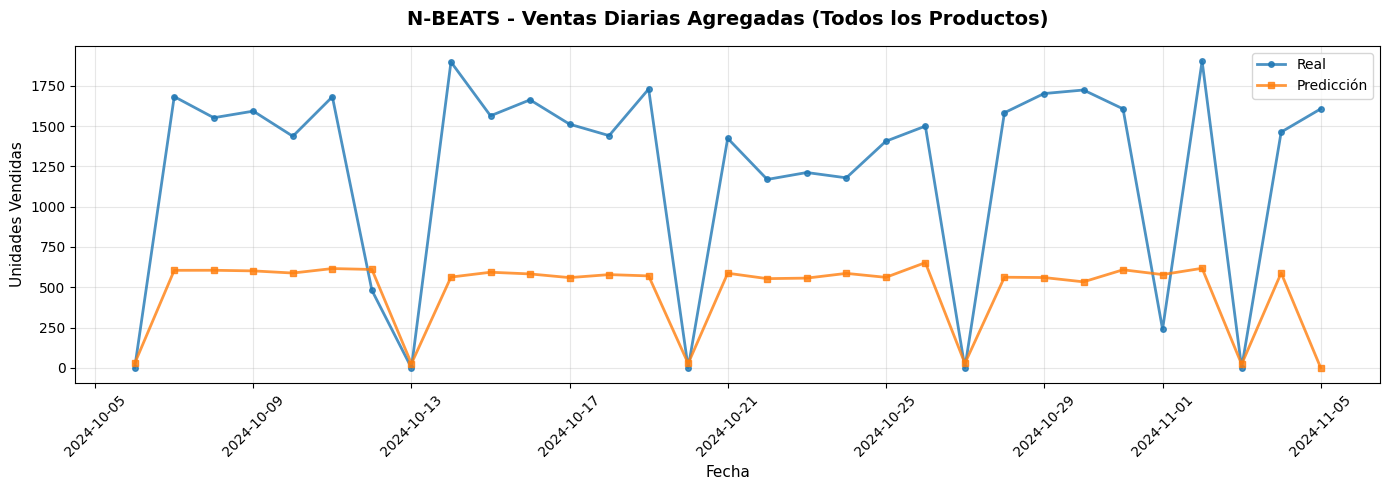


📊 Estadísticas diarias agregadas:
   MAE diario:  787.09
   RMSE diario: 897.46
   Error % medio: inf%


In [13]:
grafico_prediccion_diaria_agregada(
    df=df_test_pred,
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    titulo='N-BEATS - Ventas Diarias Agregadas (Todos los Productos)',
    figsize=(14, 5)
)

## 2. Predicciones por Cluster

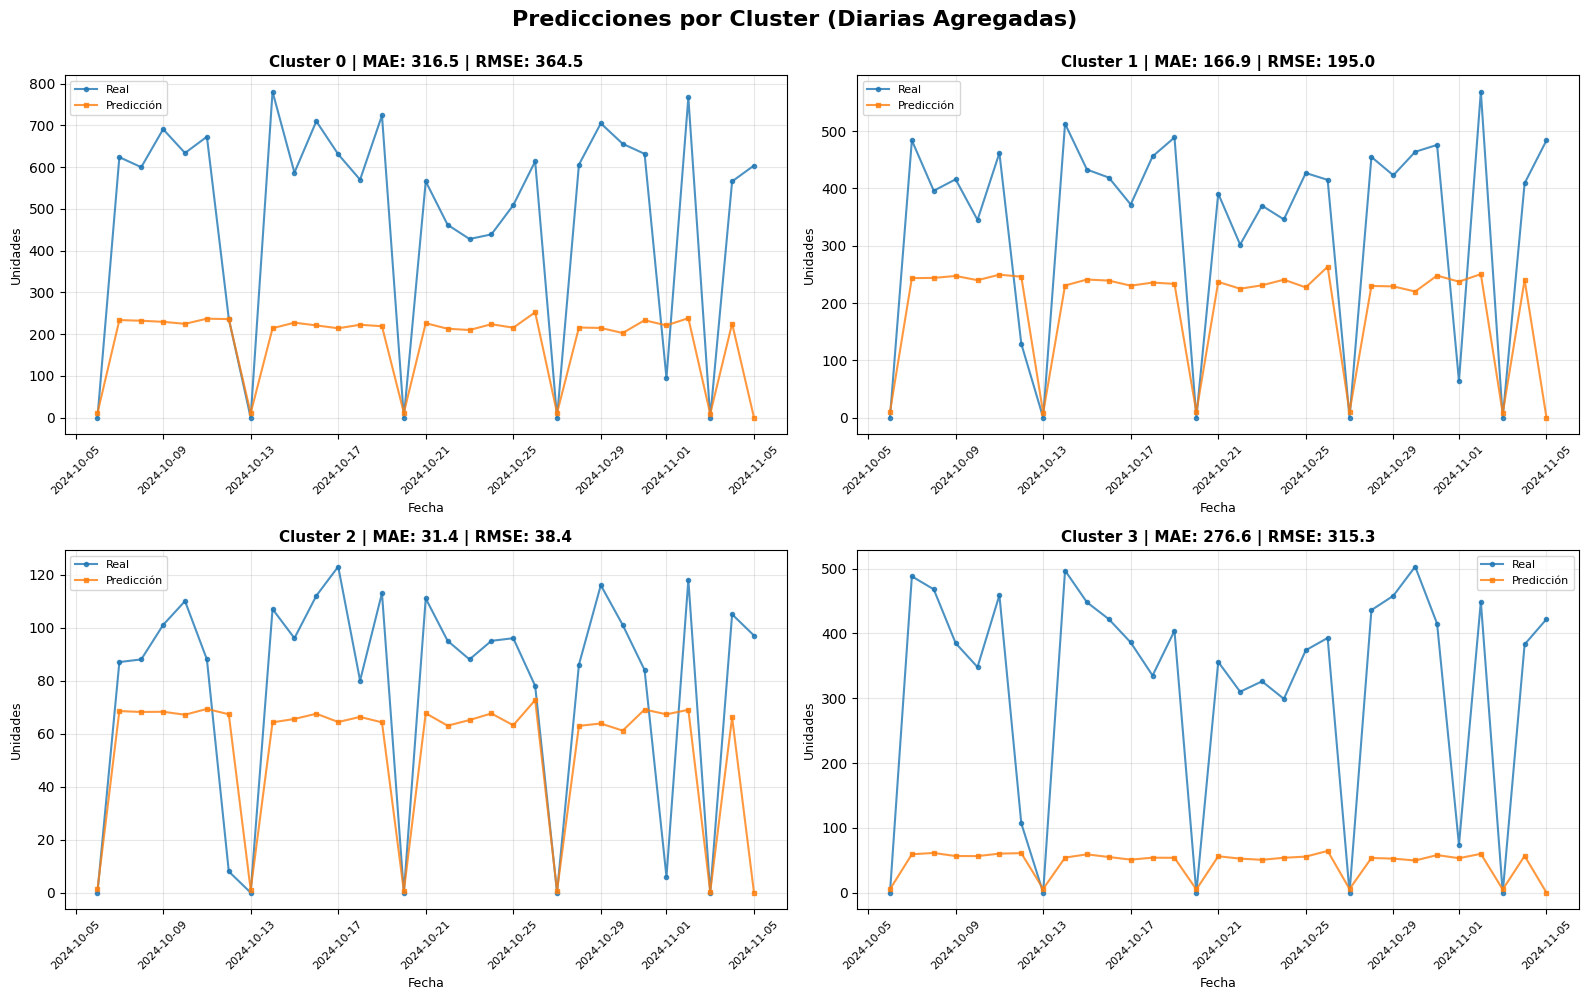

In [14]:
grafico_prediccion_por_cluster(
    df=df_test_pred,
    col_cluster='Cluster',
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    figsize=(16, 10)
)

## 3. Top 2 productos por Cluster

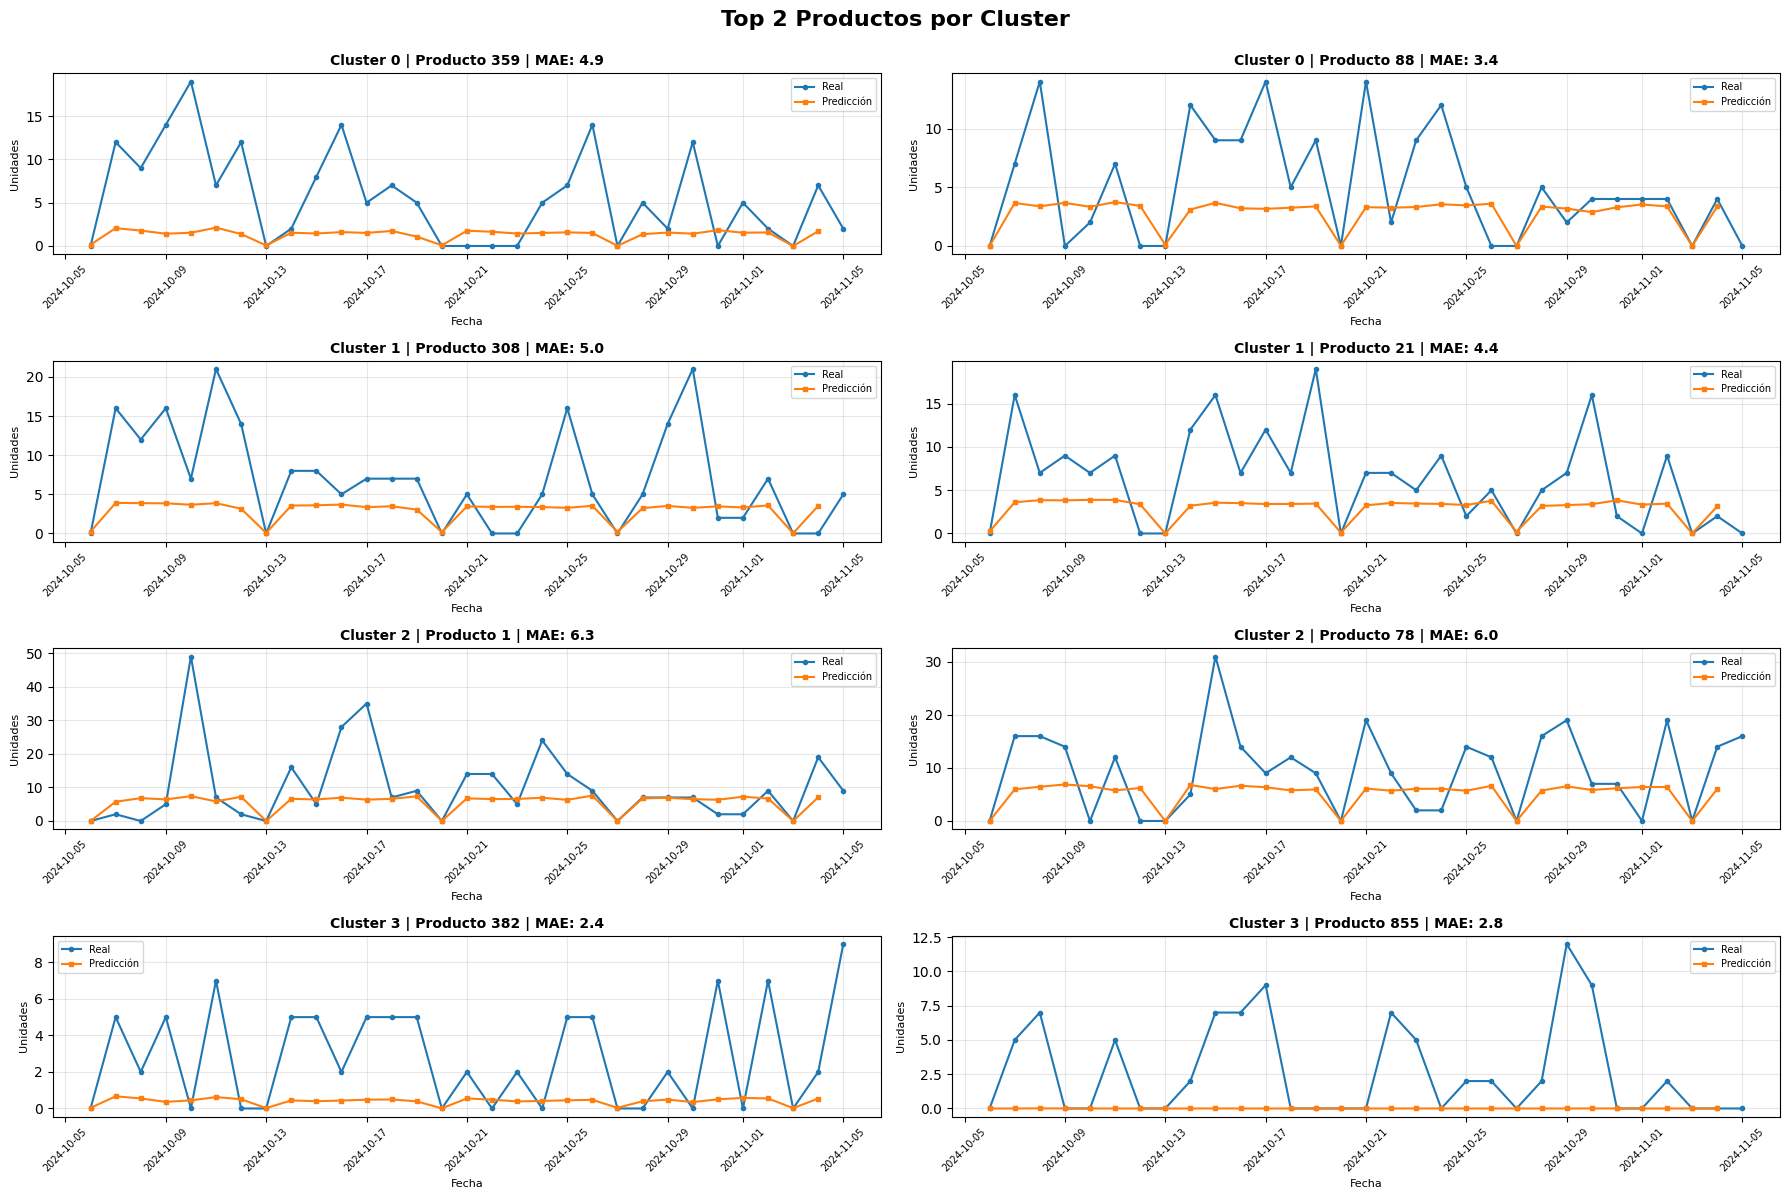

In [15]:
grafico_productos_por_cluster(
    df=df_test_pred,
    col_cluster='Cluster',
    col_producto='producto',
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    n_productos_por_cluster=2,
    figsize=(18, 12)
)

## 4. Dashboard de métricas

/workspaces/TFMDS/lib/graficos_dl.py:314: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


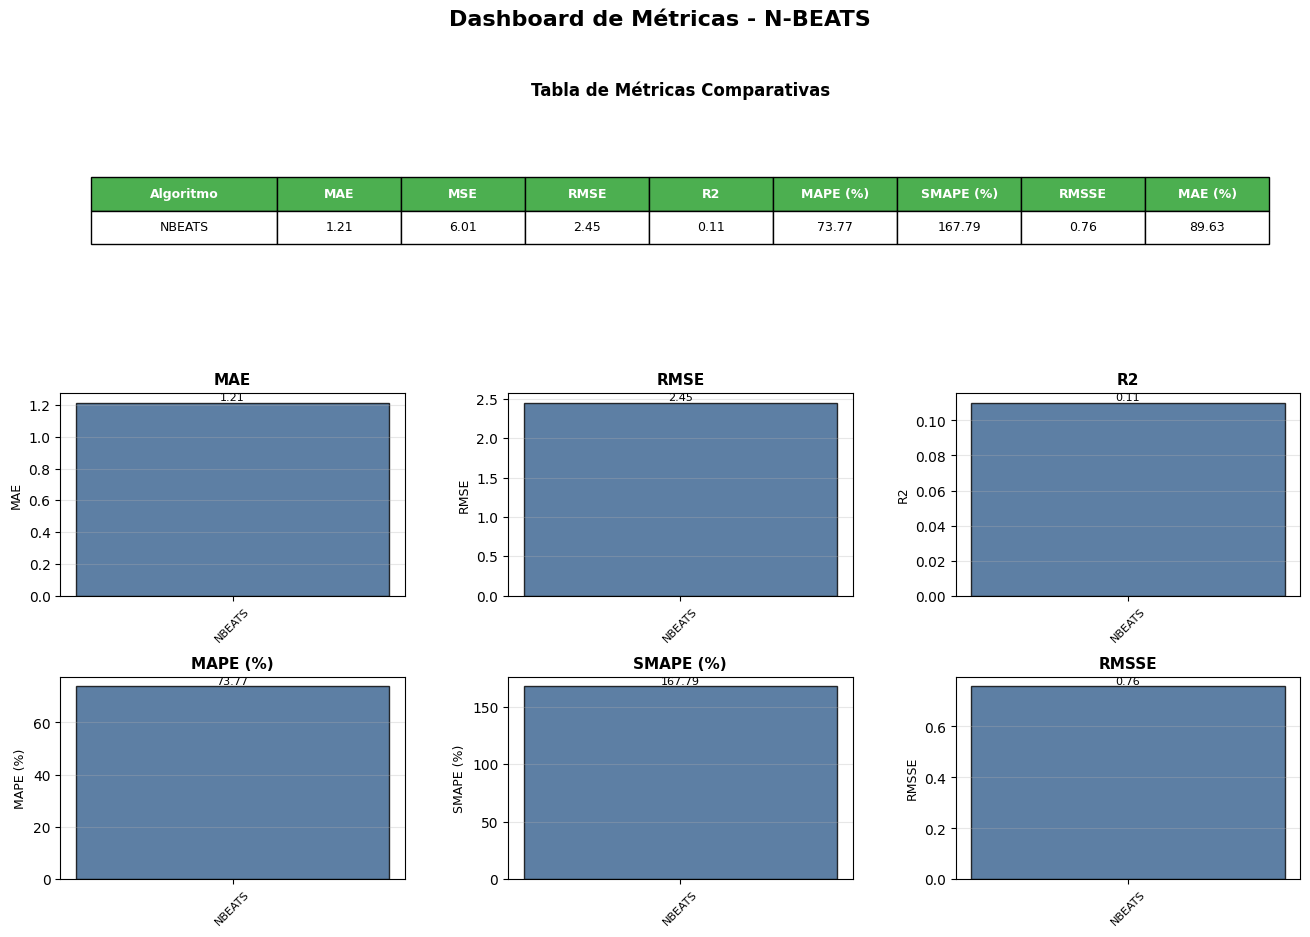

In [16]:
# Preparar diccionario de métricas para el dashboard
# La función espera: {'nombre_algoritmo': {'MAE': x, 'RMSE': y, ...}, ...}
metricas_dict = {}
for m in todas_metricas:
    nombre_algoritmo = m['Algoritmo']
    # Copiar todas las métricas excepto 'Algoritmo'
    metricas_dict[nombre_algoritmo] = {k: v for k, v in m.items() if k != 'Algoritmo'}

dashboard_metricas_dl(
    metricas_dict=metricas_dict,
    titulo='Dashboard de Métricas - N-BEATS',
    figsize=(16, 10)
)

# Guardar resultados

In [17]:
# ============================================================================
# GUARDAR RESULTADOS DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("💾 GUARDANDO RESULTADOS")
print("="*100)

# Convertir lista de métricas a DataFrame
df_resultados = pd.DataFrame(todas_metricas)

# Guardar en CSV
output_path = 'datos/resultados_metricas_nbeats.csv'
df_resultados.to_csv(output_path, index=False)

print(f"\n✅ Métricas guardadas en: {output_path}")
print(f"   Columnas: {list(df_resultados.columns)}")
print(f"\n📊 Resumen de resultados:")
print(df_resultados.to_string(index=False))
print("="*100)


💾 GUARDANDO RESULTADOS

✅ Métricas guardadas en: datos/resultados_metricas_nbeats.csv
   Columnas: ['Algoritmo', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)', 'RMSSE', 'MAE (%)']

📊 Resumen de resultados:
Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
   NBEATS 1.2147 6.0064 2.4508 0.1101     73.77     167.79 0.7573    89.63
